# Análise dos gastos públicos com viagens

Este notebook realiza a criação das views Gold e responde às perguntas de negócio utilizando consultas SQL e visualizações em Python.





**As perguntas de negócio a serem respondidas são:**

Os 5 órgãos com maior custo total? 

Os 3 destinos com maior custo médio por viagem? 

A viagem de maior duração e seu custo total? 

Qual o tipo de pagamento com maior valor médio? 

Qual o meio de transporte mais usado nos trechos? 

Qual UF de destino aparece em mais trechos? 

Qual órgão pagou mais no total? 

In [32]:
#Conexao com o banco de dados.

import pandas as pd
import matplotlib.pyplot as plt
import banco 

conexao = banco.conectar()
cursor = conexao.cursor()

print('Conexão com MySQL efetuada.')

        


Conexão com MySQL efetuada.


## Funções que serão utilizadas na Análise

Executar SQL


In [33]:

def executar(conexao, sql):
    """Executa um comando SQL simples (CREATE, DROP, INSERT...SELECT, etc.)."""
    cursor = conexao.cursor()
    cursor.execute(sql)
    conexao.commit()
    cursor.close()


Criar tabelas gold e views gold



In [34]:
def criar_gold(conexao, nome_tabela, sql):  
    # Apaga e cria tabela gold e view.
    banco.executar(conexao, f"DROP TABLE IF EXISTS gold_{nome_tabela}") 
    banco.executar(conexao, f"CREATE TABLE gold_{nome_tabela} AS {sql}")
    print(f"tabela gold_{nome_tabela} criada.")
   
    banco.executar(conexao, f"DROP VIEW IF EXISTS vw_gold_{nome_tabela}")
    banco.executar(conexao, f"CREATE VIEW vw_gold_{nome_tabela} AS {sql}")
    print(f"VIEW da tabela vw_gold_{nome_tabela} criada.")

Formatar numero como moeda brasileira

In [35]:

def reais(valor):
    """Formata um numero como moeda brasileira: 1234.5 -> 'R$ 1.234,50'."""
    texto = f'{valor:,.2f}' # 2 casas decimais e vírgula como separador de milhar, e ponto como separador decimal
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')
    # 1 - transforma a virgula em X (1X234.50)
    # 2 - transforma o ponto em vírgula (1X234,50)
    # 3 - transforma X em ponot (1.234,50)

print('Conexão com MySQL efetuada.')

Conexão com MySQL efetuada.


Consultar Silver

In [36]:

def consultar(sql):
    """Devolve o SELECT como um DataFrame""" 
    return pd.read_sql(sql, conexao)

Consultar Gold

In [37]:
def consultar_gold(conexao, nome_tabela):
    ''''''
    return pd.read_sql(f"SELECT * FROM vw_gold_{nome_tabela}", conexao)  

Configurar grafico

In [38]:
def configurar_grafico(ax, titulo, xlabel='', ylabel=''):
    ax.set_title(titulo, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    
    

## Início da Análise

Pergunta 1: Os 5 órgãos com maior custo total?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


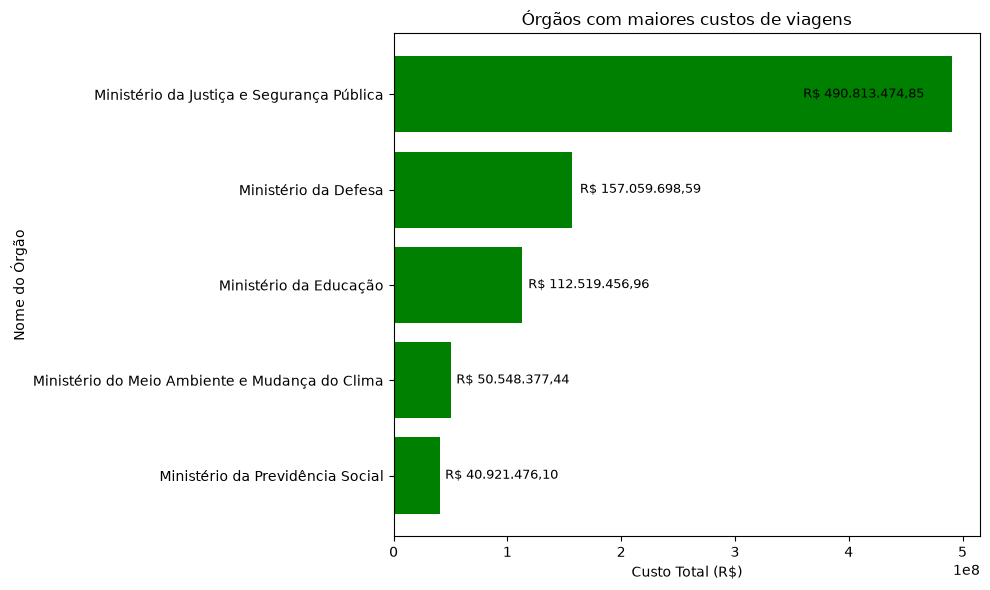

In [39]:
sql_query1 = '''
SELECT nome_orgao_superior AS nome_orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao
ORDER BY custo_total DESC
LIMIT 5;
'''

df_query1 = consultar(sql_query1)
df_query1

#Gráfico 1: Matplotlib
fig, ax = plt.subplots(figsize=(10,6)) #cria a figura e o eixo o tamanho
#grafico de barra horizontal
ax.barh(df_query1['nome_orgao'], df_query1['custo_total'], color='green') 
ax.invert_yaxis() #inverte o eixo, maior em cima (top 5). 
ax.set_title('Órgãos com maiores custos de viagens')
ax.set_xlabel('Custo Total (R$)') #eixo x
ax.set_ylabel('Nome do Órgão') #eixo y
for i, custo in enumerate(df_query1['custo_total']): #indice e custo de cada barra (orgao)
    if i == 0:  # primeira barra texto dentro
        ax.text(custo - custo*0.05, i, ' ' + reais(custo),
                va='center', ha='right',
                color='black', fontsize=9)   
    else:       # demais barras texto fora
        ax.text(custo + custo*0.02, i, ' ' + reais(custo),
                va='center', ha='left',
                color='black', fontsize=9)   
plt.tight_layout() #ajusta espaços internos para que títulos e rótulos nao sejam cortados
plt.show() #exibe o gráfico

Pergunta 2: Os 3 destinos com maior custo médio por viagem? 

tabela gold_custo_medio_destino criada.
VIEW da tabela vw_gold_custo_medio_destino criada.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3111989560.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM vw_gold_{nome_tabela}", conexao)


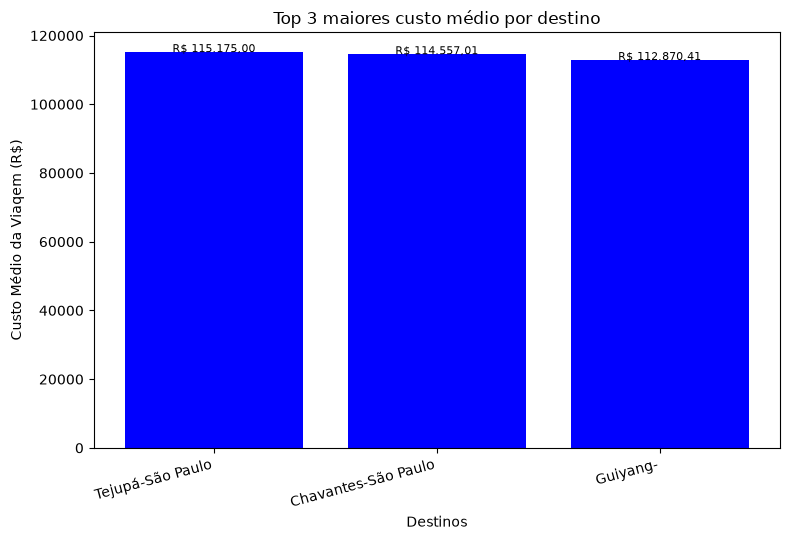

In [10]:
sql_query2 = '''
SELECT
    CONCAT(t.destino_cidade, '-',t.destino_uf) AS destino,
    AVG(v.valor_total) AS custo_medio_viagem
FROM silver_viagem v
INNER JOIN silver_trecho t
    ON v.id_viagem = t.id_viagem
GROUP BY t.destino_cidade, t.destino_uf
ORDER BY custo_medio_viagem DESC
LIMIT 3;
'''


#Criação tabela e view Gold 
criar_gold(conexao, 'custo_medio_destino', sql_query2)

# Consultar/ler a view gol
df_query2 = consultar_gold(conexao,"custo_medio_destino")
df_query2

#Gráfico 2
fig, ax = plt.subplots(figsize=(8,5.5)) 
#grafico de barra vertical
ax.bar(df_query2['destino'], df_query2['custo_medio_viagem'], color='blue') 
ax.set_title('Top 3 maiores custo médio por destino')
ax.set_xlabel('Destinos') 
ax.set_ylabel('Custo Médio da Viaqem (R$)')
plt.xticks(rotation=15, ha='right')
for i, custo_medio in enumerate(df_query2['custo_medio_viagem']):
    ax.text(i, custo_medio, reais(custo_medio), ha='center', fontsize=8)
plt.tight_layout() 
plt.show()

Pergunta 3: A viagem de maior duração e seu custo total? 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


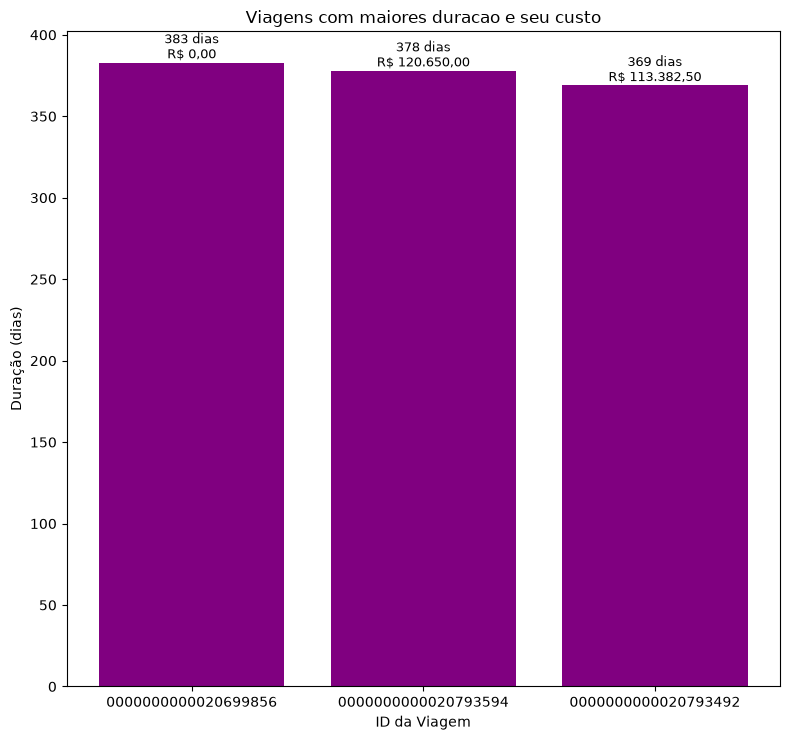

In [11]:
sql_query3 = '''
SELECT id_viagem, 
    duracao_dias AS duracao,
    valor_total AS custo_total
FROM silver_viagem
ORDER BY duracao DESC
LIMIT 3; --usado limit 3 para fazer o grafico com as 3 viagens com maior duração
'''

df_query3 = consultar(sql_query3)
df_query3

#Grafico 3
fig, ax = plt.subplots(figsize=(8,7.5)) 
ax.bar(df_query3['id_viagem'], df_query3['duracao'], color='purple') 
ax.set_title('Viagens com maiores duracao e seu custo')
ax.set_xlabel('ID da Viagem') 
ax.set_ylabel('Duração (dias)') 
for i, linha in df_query3.iterrows():
    texto_label = f"{linha['duracao']} dias\n{reais(linha['custo_total'])}"
    ax.text(i, linha['duracao'], texto_label, ha='center', va='bottom', fontsize=9)    
plt.tight_layout()
plt.show() 

Pergunta 4: Qual o tipo de pagamento com maior valor médio?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


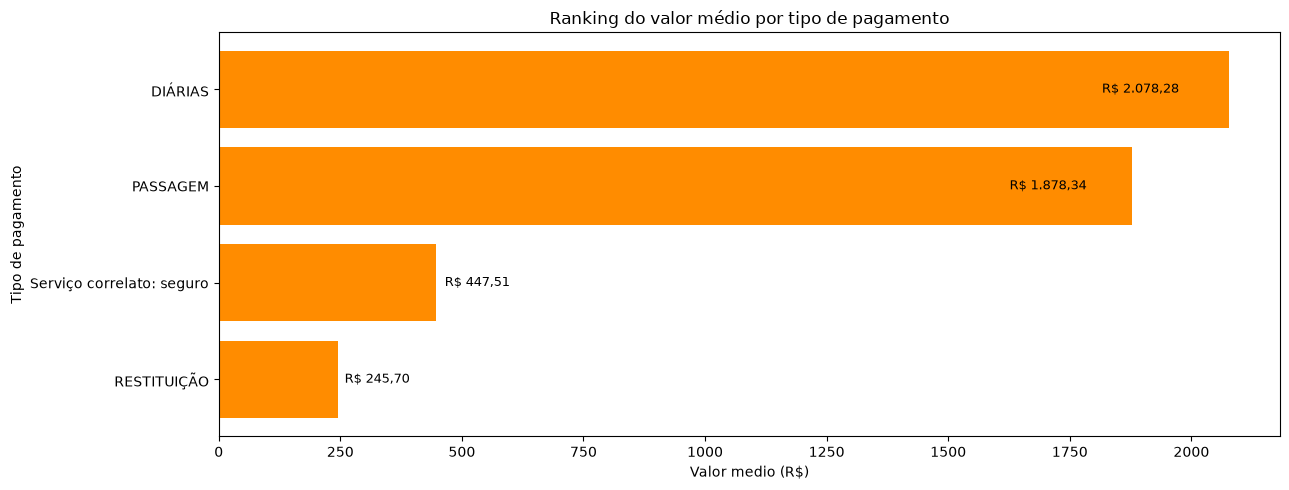

In [16]:
sql_query4 = '''
SELECT tipo_pagamento, 
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC -- sem limit para comparar todos os tipos de pagamento no gráfico.
'''

df_query4 = consultar(sql_query4)
df_query4

#Gráfico 4
fig, ax = plt.subplots(figsize=(13,5)) #cria a figura e o eixo com tamanho de 10pol x 5pol
#grafico de barra horizontal
ax.barh(df_query4['tipo_pagamento'], df_query4['valor_medio'], color='darkorange') 
ax.invert_yaxis() #inverte o eixo, maior em cima
ax.set_title('Ranking do valor médio por tipo de pagamento')
ax.set_xlabel('Valor medio (R$)') #eixo x
ax.set_ylabel('Tipo de pagamento') #eixo y
for i, valor in enumerate(df_query4['valor_medio']): 
    if i <= 1:  # as 2 primeira barras texto dentro
        ax.text(valor - valor*0.05, i, ' ' + reais(valor),
                va='center', ha='right',
                color='black', fontsize=9)   
    else:       # demais barras texto fora
        ax.text(valor + valor*0.02, i, ' ' + reais(valor),
                va='center', ha='left',
                color='black', fontsize=9)   
plt.tight_layout() #ajusta espaços internos para que títulos e rótulos nao sejam cortados
plt.show() #exibe o gráfico

Pergunta 5: Qual o meio de transporte mais usado nos trechos? 

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


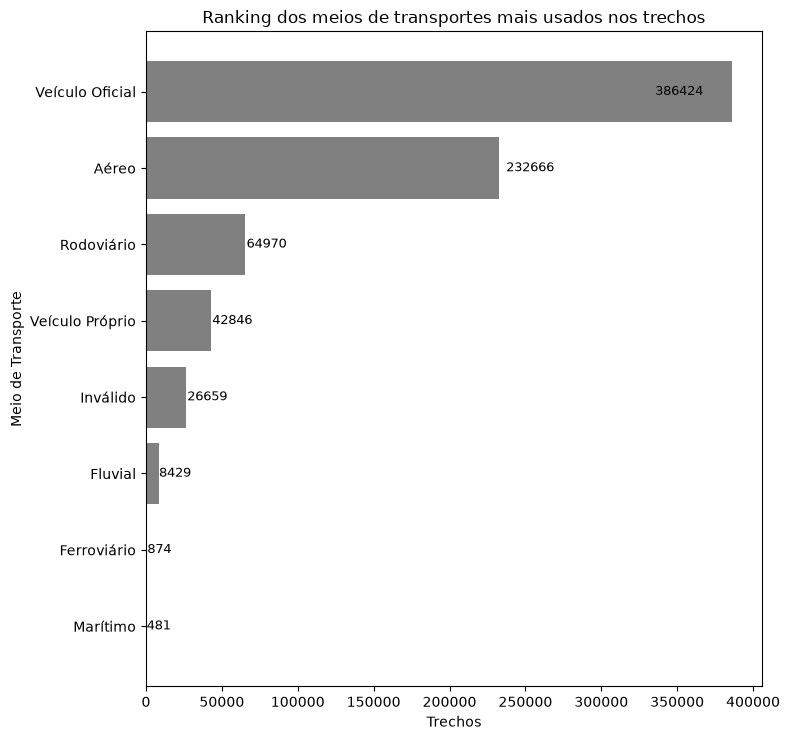

In [19]:
sql_query5 = '''
SELECT meio_transporte,
    COUNT(id_trecho) AS qtd_trecho
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY qtd_trecho DESC
 -- sem limit para comparar todos os meios de transportes no gráfico.
'''

df_query5 = consultar(sql_query5)
df_query5

#Grafico 5
fig, ax = plt.subplots(figsize=(8,7.5)) 
ax.barh(df_query5['meio_transporte'], df_query5['qtd_trecho'], color='grey') 
ax.invert_yaxis() #inverte o eixo, maior em cima
ax.set_title('Ranking dos meios de transportes mais usados nos trechos')
ax.set_xlabel('Trechos') 
ax.set_ylabel('Meio de Transporte') 
for i, trecho in enumerate(df_query5['qtd_trecho']):
    if i == 0:  # primeira barra texto dentro
        ax.text(trecho - trecho*0.05, i, str(trecho),
                va='center', ha='right',
                color='black', fontsize=9)
    else:       # demais barras texto fora
        ax.text(trecho + trecho*0.02, i, str(trecho),
                va='center', ha='left',
                color='black', fontsize=9)

plt.tight_layout()
plt.show() 

Pergunta 6: Qual UF de destino aparece em mais trechos?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


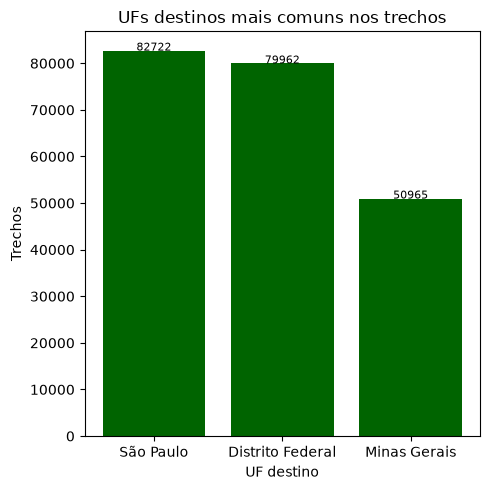

In [23]:
sql_query6 = '''
SELECT destino_uf, 
    COUNT(id_trecho) AS qtd_trecho
FROM silver_trecho
GROUP BY destino_uf
ORDER BY qtd_trecho DESC
LIMIT 3; -- para mostrar as 3 UFs de destinos que mais aparecem nos trechos.
'''

df_query6 = consultar(sql_query6)
df_query6

#Grafico 6
fig, ax = plt.subplots(figsize=(5,5)) 
ax.bar(df_query6['destino_uf'], df_query6['qtd_trecho'], color='darkgreen') 
ax.set_title('UFs destinos mais comuns nos trechos')
ax.set_xlabel('UF destino') 
ax.set_ylabel('Trechos') 
for i, trecho in enumerate(df_query6['qtd_trecho']):
    ax.text(i, trecho, str(trecho), ha='center', fontsize=8)  
plt.tight_layout()
plt.show() 

Pergunta 7: Qual órgão pagou mais no total?

C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3127764268.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


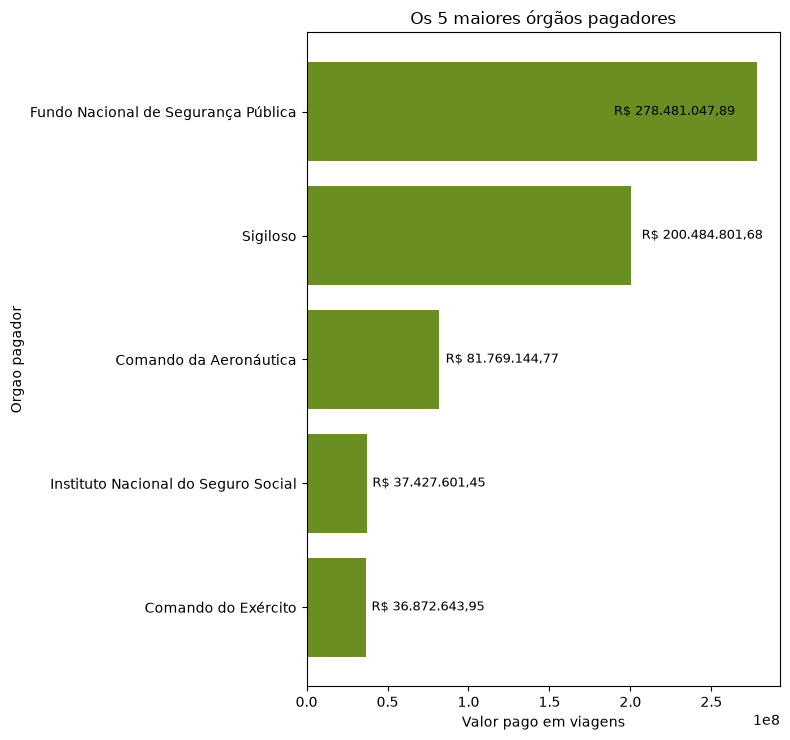

In [27]:
sql_query7 = '''
SELECT nome_orgao_pagador AS orgao_pagador,
    SUM(valor) AS valor_total_pago
FROM silver_pagamento
GROUP BY orgao_pagador
ORDER BY valor_total_pago DESC
LIMIT 5; -- para mostrar os 5 maiores orgaos pagadores
'''

df_query7 = consultar(sql_query7)
df_query7

#Grafico 7
fig, ax = plt.subplots(figsize=(8,7.5)) 
ax.barh(df_query7['orgao_pagador'], df_query7['valor_total_pago'], color='olivedrab') 
ax.invert_yaxis() #inverte o eixo, maior em cima
ax.set_title('Os 5 maiores órgãos pagadores')
ax.set_xlabel('Valor pago em viagens') 
ax.set_ylabel('Orgao pagador') 
for i, valor in enumerate(df_query7['valor_total_pago']):
    if i == 0:  # primeira barra texto dentro
        ax.text(valor - valor*0.05, i, ' ' + reais(valor),
                va='center', ha='right',
                color='black', fontsize=9)   
    else:       # demais barras texto fora
        ax.text(valor + valor*0.02, i, ' ' + reais(valor),
                va='center', ha='left',
                color='black', fontsize=9)   
plt.tight_layout()
plt.show() 

### PERGUNTAS EXTRAS PARA FAZER JOIN E AGREGAÇÕES (CAMADA GOLD)

Qual o custo médio das viagens por meio de transporte?

tabela gold_custo_medio_meio_transporte criada.
VIEW da tabela vw_gold_custo_medio_meio_transporte criada.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3111989560.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM vw_gold_{nome_tabela}", conexao)


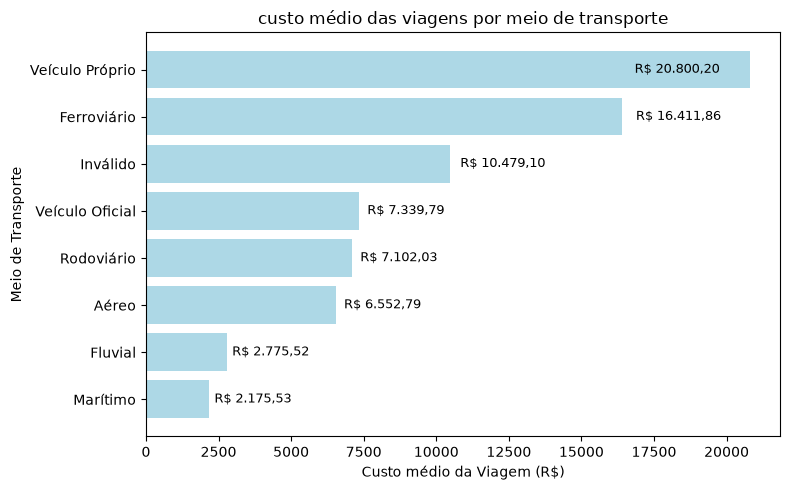

In [30]:
sql_extra1 = '''
SELECT
    t.meio_transporte,
    AVG(v.valor_total) AS custo_medio_viagem
FROM silver_viagem v
INNER JOIN silver_trecho t
    ON v.id_viagem = t.id_viagem
GROUP BY t.meio_transporte
ORDER BY custo_medio_viagem DESC
'''

#Criação tabela e view Gold 
criar_gold(conexao, 'custo_medio_meio_transporte', sql_extra1)

# Consultar/ler a view gold
df_extra1 = consultar_gold(conexao,"custo_medio_meio_transporte")
df_extra1

#Grafico extra 1
fig, ax = plt.subplots(figsize=(8,5)) 
ax.barh(df_extra1['meio_transporte'], df_extra1['custo_medio_viagem'], color='lightblue') 
ax.invert_yaxis()
ax.set_title('custo médio das viagens por meio de transporte')
ax.set_xlabel('Custo médio da Viagem (R$)') 
ax.set_ylabel('Meio de Transporte') 
for i, custo in enumerate(df_extra1['custo_medio_viagem']):
    if i == 0:  # primeira barra texto dentro
        ax.text(custo - custo*0.05, i, ' ' + reais(custo),
            va='center', ha='right',
            color='black', fontsize=9)   
    else:    # demais barras texto fora
        ax.text(custo + custo*0.02, i, ' ' + reais(custo),
            va='center', ha='left',
            color='black', fontsize=9)  
plt.tight_layout()
plt.show() 



### Qual os 3 UFs de destino com maior custo médio das viagens?

tabela gold_custo_medio_uf_destino criada.
VIEW da tabela vw_gold_custo_medio_uf_destino criada.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_14636\3111989560.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(f"SELECT * FROM vw_gold_{nome_tabela}", conexao)


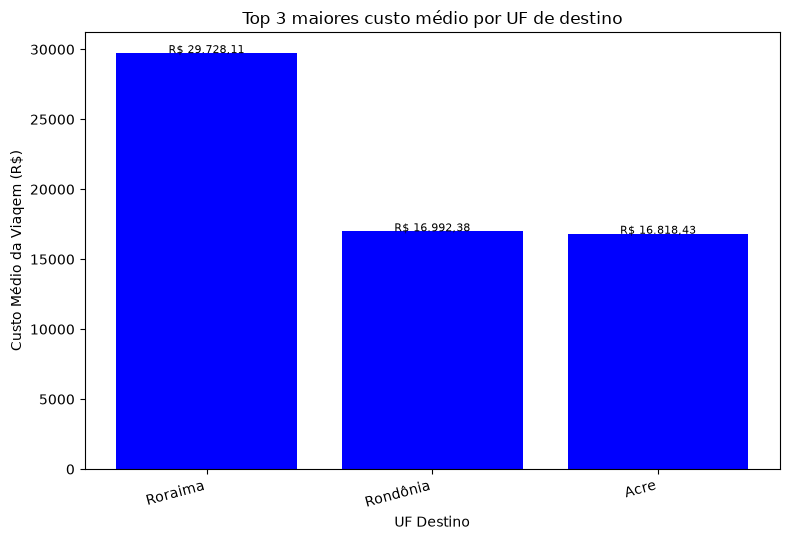

In [31]:
sql_extra2 = '''
SELECT
    t.destino_uf AS uf_destino,
    AVG(v.valor_total) AS custo_medio_viagem
FROM silver_viagem v
INNER JOIN silver_trecho t
    ON v.id_viagem = t.id_viagem
GROUP BY uf_destino
ORDER BY custo_medio_viagem DESC
LIMIT 3;
'''

criar_gold(conexao, 'custo_medio_uf_destino', sql_extra2)

df_extra2 = consultar_gold(conexao, 'custo_medio_uf_destino')
df_extra2

#Grafico extra 2
fig, ax = plt.subplots(figsize=(8,5.5)) 
#grafico de barra vertical
ax.bar(df_extra2['uf_destino'], df_extra2['custo_medio_viagem'], color='blue') 
ax.set_title('Top 3 maiores custo médio por UF de destino')
ax.set_xlabel('UF Destino') 
ax.set_ylabel('Custo Médio da Viaqem (R$)')
plt.xticks(rotation=15, ha='right')
for i, custo_medio in enumerate(df_extra2['custo_medio_viagem']):
    ax.text(i, custo_medio, reais(custo_medio), ha='center', fontsize=8)
plt.tight_layout() 
plt.show()